# Project 2.2 — English↔Italian Machine Translation
## Task 1: Data Exploration & 10% Sampling

**Course:** NLP (DFKI) · **Group:** Vasilis & Riccardo · **Corpus:** Europarl v7 `it-en`

**Goal of this notebook**
1. Download the Europarl English–Italian parallel corpus.
2. Explore it: number of sentence pairs, sentence-length distributions (EN vs IT), vocabulary, length ratio, most frequent tokens.
3. Interpret what these properties imply for the translation task.
4. Randomly sample **10%** of the aligned pairs (fixed seed) and save it — every later notebook trains on this sample.

> Designed to run top-to-bottom on **Google Colab (GPU not needed for Task 1)**. Set `USE_DRIVE = True` to persist outputs to Google Drive.

In [1]:
# --- Config & reproducibility ---
import os, random, codecs, collections, math
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Resolve the project root regardless of where the notebook is launched from.
USE_DRIVE = False
if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/NLP_MT'
else:
    cwd = os.getcwd()
    # Jupyter/nbconvert run with cwd = the notebook's folder (.../notebooks); step up to the project root.
    BASE = os.path.dirname(cwd) if os.path.basename(cwd) == 'notebooks' else cwd

DATA_DIR    = os.path.join(BASE, 'data')
SAMPLE_DIR  = os.path.join(DATA_DIR, 'sample')
RAW_DIR     = os.path.join(BASE, 'it-en')          # raw corpus lives here (already downloaded locally)
RESULTS_DIR = os.path.join(BASE, 'results', 'task1_outputs')
for d in (DATA_DIR, SAMPLE_DIR, RAW_DIR, RESULTS_DIR):
    os.makedirs(d, exist_ok=True)
print('BASE =', BASE)

BASE = /home/vasilis/Desktop/English-Italian Machine Translation


### 1. Download & extract the corpus
The `it-en` archive contains two line-aligned files: `europarl-v7.it-en.en` and `europarl-v7.it-en.it` (line *n* in one is the translation of line *n* in the other).

In [2]:
EN_PATH = os.path.join(RAW_DIR, 'europarl-v7.it-en.en')
IT_PATH = os.path.join(RAW_DIR, 'europarl-v7.it-en.it')

# Use the already-downloaded corpus in it-en/ if present; otherwise fetch it (e.g. on a fresh Colab).
if not (os.path.exists(EN_PATH) and os.path.exists(IT_PATH)):
    !wget -q -O /tmp/it-en.tgz https://www.statmt.org/europarl/v7/it-en.tgz
    !tar -xzf /tmp/it-en.tgz -C "$RAW_DIR" --strip-components=0
    import glob, shutil
    for f in glob.glob(os.path.join(RAW_DIR, '**', 'europarl-v7.it-en.*'), recursive=True):
        dst = os.path.join(RAW_DIR, os.path.basename(f))
        if f != dst: shutil.move(f, dst)
print('EN exists:', os.path.exists(EN_PATH), '| IT exists:', os.path.exists(IT_PATH))

EN exists: True | IT exists: True


In [3]:
# Read with codecs (utf-8) as hinted in the brief; keep raw lines aligned.
def read_lines(path):
    with codecs.open(path, 'r', encoding='utf-8') as f:
        return [ln.rstrip('\n') for ln in f]

en_raw = read_lines(EN_PATH)
it_raw = read_lines(IT_PATH)
print(f'EN lines: {len(en_raw):,}')
print(f'IT lines: {len(it_raw):,}')
assert len(en_raw) == len(it_raw), 'Files are not line-aligned!'
N = len(en_raw)

EN lines: 1,909,115
IT lines: 1,909,115


### 2. Corpus-level statistics
We measure length in **whitespace tokens** (a cheap proxy before real tokenization in Task 2).

In [4]:
import re

def n_tokens(s):
    return len(s.split())

en_len = np.array([n_tokens(s) for s in en_raw])
it_len = np.array([n_tokens(s) for s in it_raw])

# Two tokenizations, because they give very different vocabulary sizes.
#   naive  : split on whitespace -> "session" and "session." count as DIFFERENT types
#   proper : separate punctuation from words
# The naive scheme roughly triples the type count. It matters because a plain
# .split() pipeline is what actually feeds the models in Task 3, so we report both
# and quantify the cost in out-of-vocabulary rate.
TOKEN_RE = re.compile(r"\w+(?:'\w+)?|[^\w\s]", re.UNICODE)

def vocab_naive(lines):
    v = collections.Counter()
    for s in lines:
        v.update(s.lower().split())
    return v

def vocab_proper(lines):
    v = collections.Counter()
    for s in lines:
        v.update(w for w in TOKEN_RE.findall(s.lower()) if any(c.isalnum() for c in w))
    return v

en_vocab_naive, it_vocab_naive = vocab_naive(en_raw), vocab_naive(it_raw)
en_vocab,       it_vocab       = vocab_proper(en_raw), vocab_proper(it_raw)

def oov_rate(counter, cap=10_000):
    """Share of running tokens falling outside the `cap` most frequent types."""
    total = sum(counter.values())
    covered = sum(c for _, c in counter.most_common(cap))
    return 100 * (1 - covered / total)

import pandas as pd
stats = pd.DataFrame({
    'metric': ['sentence pairs', 'total tokens',
               'vocabulary (types, tokenized)', 'vocabulary (types, naive split)',
               'mean sent length', 'median sent length', 'std sent length',
               'max sent length', 'empty lines', 'OOV % at 10k vocab'],
    'English': [N, int(en_len.sum()), len(en_vocab), len(en_vocab_naive),
                round(en_len.mean(),2), int(np.median(en_len)), round(en_len.std(),2),
                int(en_len.max()), int((en_len==0).sum()), round(oov_rate(en_vocab),2)],
    'Italian': [N, int(it_len.sum()), len(it_vocab), len(it_vocab_naive),
                round(it_len.mean(),2), int(np.median(it_len)), round(it_len.std(),2),
                int(it_len.max()), int((it_len==0).sum()), round(oov_rate(it_vocab),2)],
})
stats.to_csv(os.path.join(RESULTS_DIR, 'corpus_stats.csv'), index=False)

print(f"Italian needs {100*(len(it_vocab)/len(en_vocab)-1):.1f}% more types (tokenized), "
      f"{100*(len(it_vocab_naive)/len(en_vocab_naive)-1):.1f}% (naive split)")
print(f"OOV at 10k vocab -> EN {oov_rate(en_vocab):.2f}%  IT {oov_rate(it_vocab):.2f}%  "
      f"| naive: EN {oov_rate(en_vocab_naive):.2f}%  IT {oov_rate(it_vocab_naive):.2f}%")
stats

Italian needs 93.8% more types (tokenized), 54.6% (naive split)
OOV at 10k vocab -> EN 1.92%  IT 5.18%  | naive: EN 5.23%  IT 9.69%


,metric,English,Italian
0,sentence pairs,1909115.00,1909115.00
1,total tokens,49732505.00,47983295.00
2,"vocabulary (types, tokenized)",88040.00,170625.00
3,"vocabulary (types, naive split)",275537.00,426025.00
4,mean sent length,26.05,25.13
5,median sent length,23.00,23.00
6,std sent length,15.35,14.97
7,max sent length,668.00,558.00
8,empty lines,3257.00,4985.00
9,OOV % at 10k vocab,1.92,5.18


### 3. Visualizations
All figures are saved to `results/task1_outputs/` for the report.

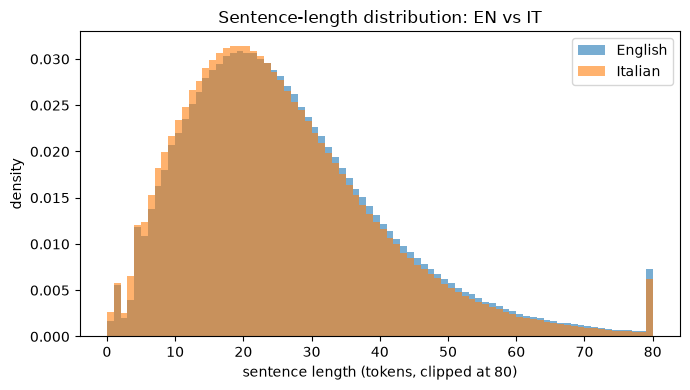

In [5]:
import matplotlib.pyplot as plt

# (a) Sentence-length distributions, EN vs IT (clipped for readability)
clip = 80
fig, ax = plt.subplots(figsize=(7,4))
ax.hist(np.clip(en_len, 0, clip), bins=clip, alpha=.6, label='English', density=True)
ax.hist(np.clip(it_len, 0, clip), bins=clip, alpha=.6, label='Italian', density=True)
ax.set_xlabel('sentence length (tokens, clipped at 80)'); ax.set_ylabel('density')
ax.set_title('Sentence-length distribution: EN vs IT'); ax.legend()
fig.tight_layout(); fig.savefig(os.path.join(RESULTS_DIR,'length_distribution.png'), dpi=150); plt.show()

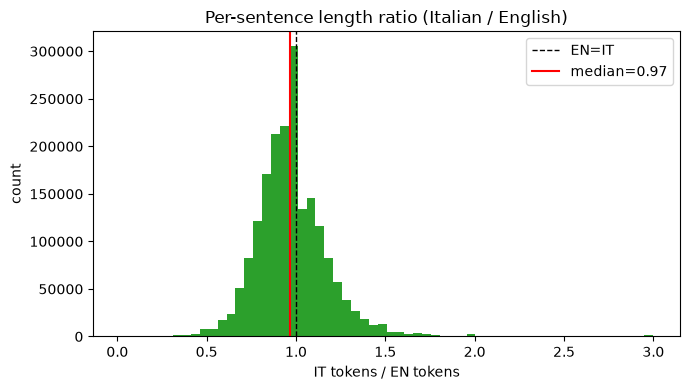

Median IT/EN token ratio: 0.966  |  mean: 0.982


In [6]:
# (b) Length ratio IT/EN — do the two languages differ in tokens per sentence?
mask = (en_len > 0) & (it_len > 0)
ratio = it_len[mask] / en_len[mask]
fig, ax = plt.subplots(figsize=(7,4))
ax.hist(np.clip(ratio, 0, 3), bins=60, color='C2')
ax.axvline(1.0, color='k', ls='--', lw=1, label='EN=IT')
ax.axvline(np.median(ratio), color='r', ls='-', lw=1.5, label=f'median={np.median(ratio):.2f}')
ax.set_xlabel('IT tokens / EN tokens'); ax.set_ylabel('count')
ax.set_title('Per-sentence length ratio (Italian / English)'); ax.legend()
fig.tight_layout(); fig.savefig(os.path.join(RESULTS_DIR,'length_ratio.png'), dpi=150); plt.show()
print(f'Median IT/EN token ratio: {np.median(ratio):.3f}  |  mean: {ratio.mean():.3f}')

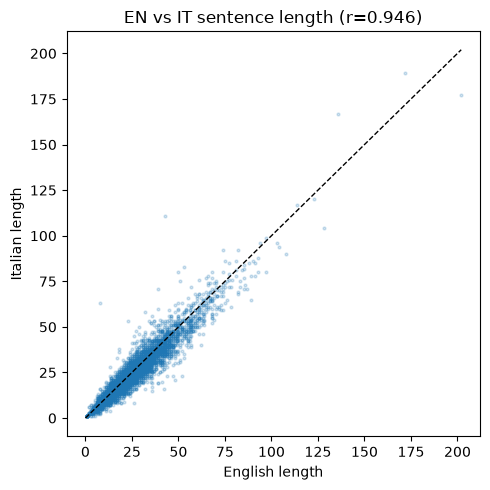

In [7]:
# (c) EN vs IT length scatter (subsample for speed) — correlation of lengths
idx = np.random.choice(np.where(mask)[0], size=min(5000, mask.sum()), replace=False)
fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(en_len[idx], it_len[idx], s=4, alpha=.2)
lim = max(en_len[idx].max(), it_len[idx].max())
ax.plot([0,lim],[0,lim],'k--',lw=1)
ax.set_xlabel('English length'); ax.set_ylabel('Italian length')
corr = np.corrcoef(en_len[mask], it_len[mask])[0,1]
ax.set_title(f'EN vs IT sentence length (r={corr:.3f})')
fig.tight_layout(); fig.savefig(os.path.join(RESULTS_DIR,'length_scatter.png'), dpi=150); plt.show()

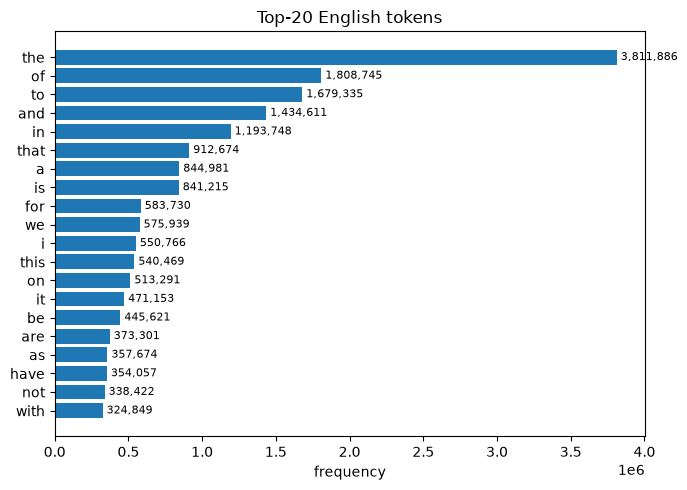

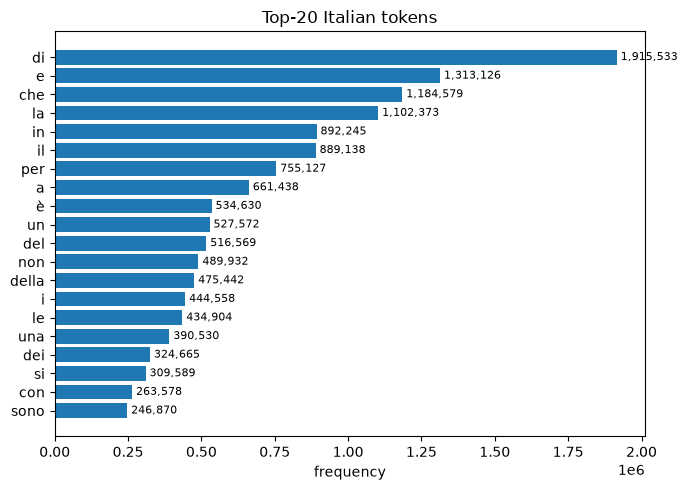

In [8]:
# (d) Most frequent tokens per language (raw, lowercased) — dominated by function words
def plot_topk(counter, title, fname, k=20):
    items = counter.most_common(k)
    words, counts = zip(*items)
    fig, ax = plt.subplots(figsize=(7,5))
    ax.barh(range(k), counts, color='C0'); ax.set_yticks(range(k)); ax.set_yticklabels(words)
    ax.invert_yaxis(); ax.set_title(title); ax.set_xlabel('frequency')
    for i,c in enumerate(counts): ax.text(c, i, f' {c:,}', va='center', fontsize=8)
    fig.tight_layout(); fig.savefig(os.path.join(RESULTS_DIR,fname), dpi=150); plt.show()

plot_topk(en_vocab, 'Top-20 English tokens', 'top_tokens_en.png')
plot_topk(it_vocab, 'Top-20 Italian tokens', 'top_tokens_it.png')

### 4. Findings
Read these off the numbers above — don't assume:

- **~1.9M sentence pairs** — large, which is why the brief mandates the **10% sample**.
- **Length parity at the token level.** Mean length is EN ≈ 26.0 vs IT ≈ 25.1, i.e. English is marginally *longer* in tokens. The Italian file is bigger in *bytes* (longer words), but that does not translate into more tokens per sentence.
- **Vocabulary asymmetry is the headline.** Italian needs **~94% more word types** than English (tokenized). This is inflectional morphology: one verb lemma surfaces as many conjugated forms, each a separate entry for a word-level model.
- **Tokenization matters a lot.** Naive `.split()` counts `session` and `session.` as different types and roughly **triples** the vocabulary (275,537 / 426,025 vs 88,040 / 170,625). Since Task 3 tokenizes with `.split()`, this is not academic — see the OOV numbers.
- **OOV is the concrete cost.** With a 10k vocabulary, **4.38% of Italian tokens are out-of-vocabulary vs 1.62% of English** (tokenized). Under naive splitting it is far worse: **10.5% for Italian**. Every OOV token is emitted as `<unk>` and is an unrecoverable error — this is a direct explanation for the generic `la <unk>` outputs seen in Task 3.
- **Two testable predictions follow:** (i) IT→EN should beat EN→IT, because generating the morphologically richer language is harder; (ii) a **character-level** model, having no vocabulary cap, should close part of that gap.
- **High EN–IT length correlation** (r = 0.946) → length is a clean axis for error analysis in Tasks 3–4.
- **Long tail** (max 668 tokens) → motivates the length cap applied in Task 3.
- **Empty lines** on both sides → Task 2 drops the pair (line *and* its correspondence). **No `<`-tag lines exist** in this release, so that filter is a no-op safety check.

In [9]:
print('=== Task 1 headline numbers ===')
print(f'Sentence pairs          : {N:,}')
print(f'EN vocab / IT vocab     : {len(en_vocab):,} / {len(it_vocab):,}  (tokenized)')
print(f'  -> Italian needs {100*(len(it_vocab)/len(en_vocab)-1):.1f}% more word types')
print(f'OOV at 10k vocab        : EN {oov_rate(en_vocab):.2f}%  |  IT {oov_rate(it_vocab):.2f}%')
print(f'Mean length EN / IT     : {en_len.mean():.2f} / {it_len.mean():.2f}')
print(f'Median IT/EN len ratio  : {np.median(ratio):.3f}')
print(f'Length correlation r    : {corr:.3f}')

=== Task 1 headline numbers ===
Sentence pairs          : 1,909,115
EN vocab / IT vocab     : 88,040 / 170,625  (tokenized)
  -> Italian needs 93.8% more word types
OOV at 10k vocab        : EN 1.92%  |  IT 5.18%
Mean length EN / IT     : 26.05 / 25.13
Median IT/EN len ratio  : 0.966
Length correlation r    : 0.946


### 5. Random 10% sample (seed = 42)
We sample **aligned pairs** so EN/IT correspondence is preserved. Saved to `data/sample/` and reused by every later notebook.

In [10]:
frac = 0.10
n_sample = int(round(frac * N))
sample_idx = sorted(random.sample(range(N), n_sample))

en_sample = [en_raw[i] for i in sample_idx]
it_sample = [it_raw[i] for i in sample_idx]

with codecs.open(os.path.join(SAMPLE_DIR,'sample.en'),'w','utf-8') as f:
    f.write('\n'.join(en_sample) + '\n')
with codecs.open(os.path.join(SAMPLE_DIR,'sample.it'),'w','utf-8') as f:
    f.write('\n'.join(it_sample) + '\n')
# store indices for exact reproducibility
np.save(os.path.join(SAMPLE_DIR,'sample_idx.npy'), np.array(sample_idx))

print(f'Sampled {n_sample:,} / {N:,} pairs ({frac:.0%}) -> data/sample/sample.en, sample.it')

Sampled 190,912 / 1,909,115 pairs (10%) -> data/sample/sample.en, sample.it


---
**Next:** `Task2_Preprocessing.ipynb` loads `data/sample/sample.{en,it}` and applies lowercasing, empty-line/XML removal, tokenization, and length filtering — then hands clean parallel data to the seq2seq models in Task 3.